# 🌸 CodeAlpha - Task 1: Iris Flower Classification

**Nama:** Annisa Yusri Nur Rochmah

**Program:** CodeAlpha Data Science Internship

## Tujuan
Membangun model machine learning untuk mengklasifikasikan spesies bunga Iris (*setosa*, *versicolor*, *virginica*) berdasarkan 4 fitur pengukuran: panjang & lebar sepal, panjang & lebar petal.

## Alur Kerja
1. Load & eksplorasi dataset (EDA)
2. Visualisasi distribusi & hubungan antar fitur
3. Preprocessing (train-test split, scaling)
4. Training beberapa model klasifikasi
5. Evaluasi & perbandingan performa model
6. Kesimpulan


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 2. Load Dataset

In [3]:
iris = load_iris()
df = pd.read_csv("Iris.csv")
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
df.head()


Shape: (150, 7)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa,setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa,setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa,setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa,setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa,setosa


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             150 non-null    int64   
 1   SepalLengthCm  150 non-null    float64 
 2   SepalWidthCm   150 non-null    float64 
 3   PetalLengthCm  150 non-null    float64 
 4   PetalWidthCm   150 non-null    float64 
 5   Species        150 non-null    object  
 6   species        150 non-null    category
dtypes: category(1), float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [5]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nJumlah data per spesies:")
print(df["species"].value_counts())


Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
species          0
dtype: int64

Jumlah data per spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### 3.1 Distribusi Setiap Fitur per Spesies

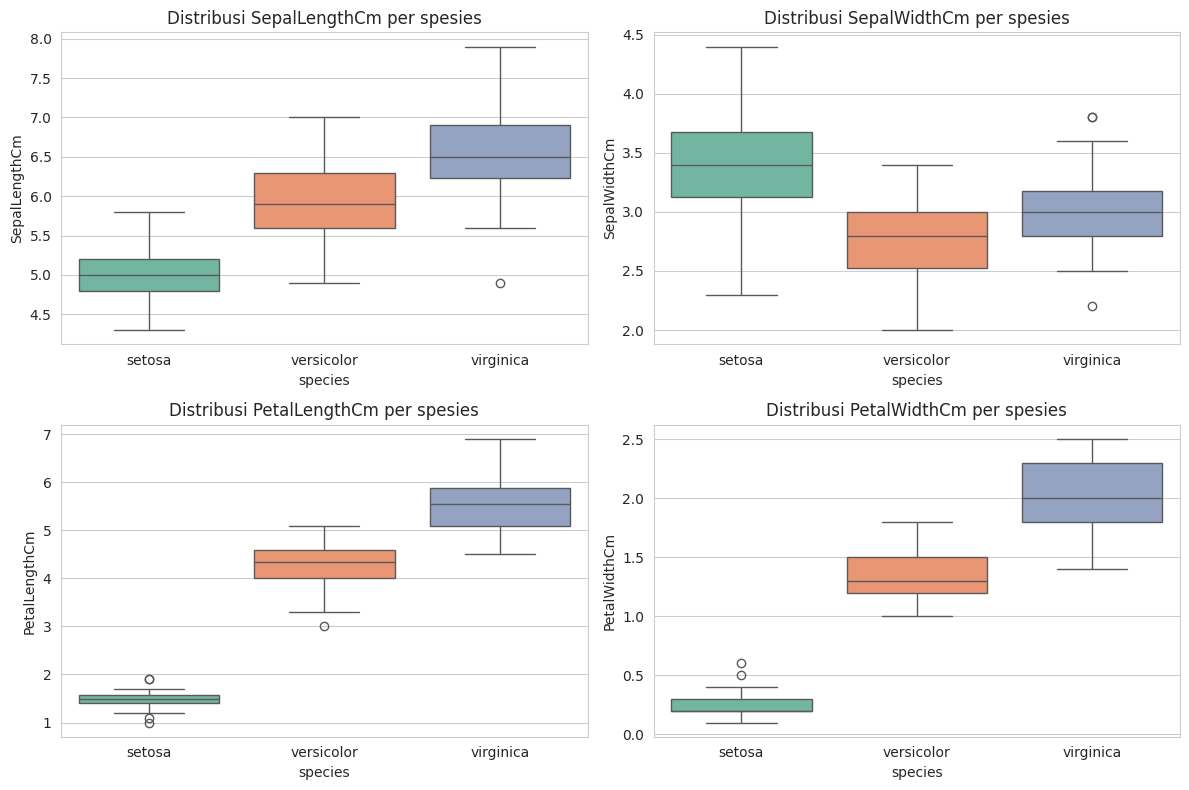

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feat, hue="species", ax=ax, palette="Set2", legend=False)
    ax.set_title(f"Distribusi {feat} per spesies")
plt.tight_layout()
plt.show()

### 3.2 Pairplot — Hubungan Antar Fitur

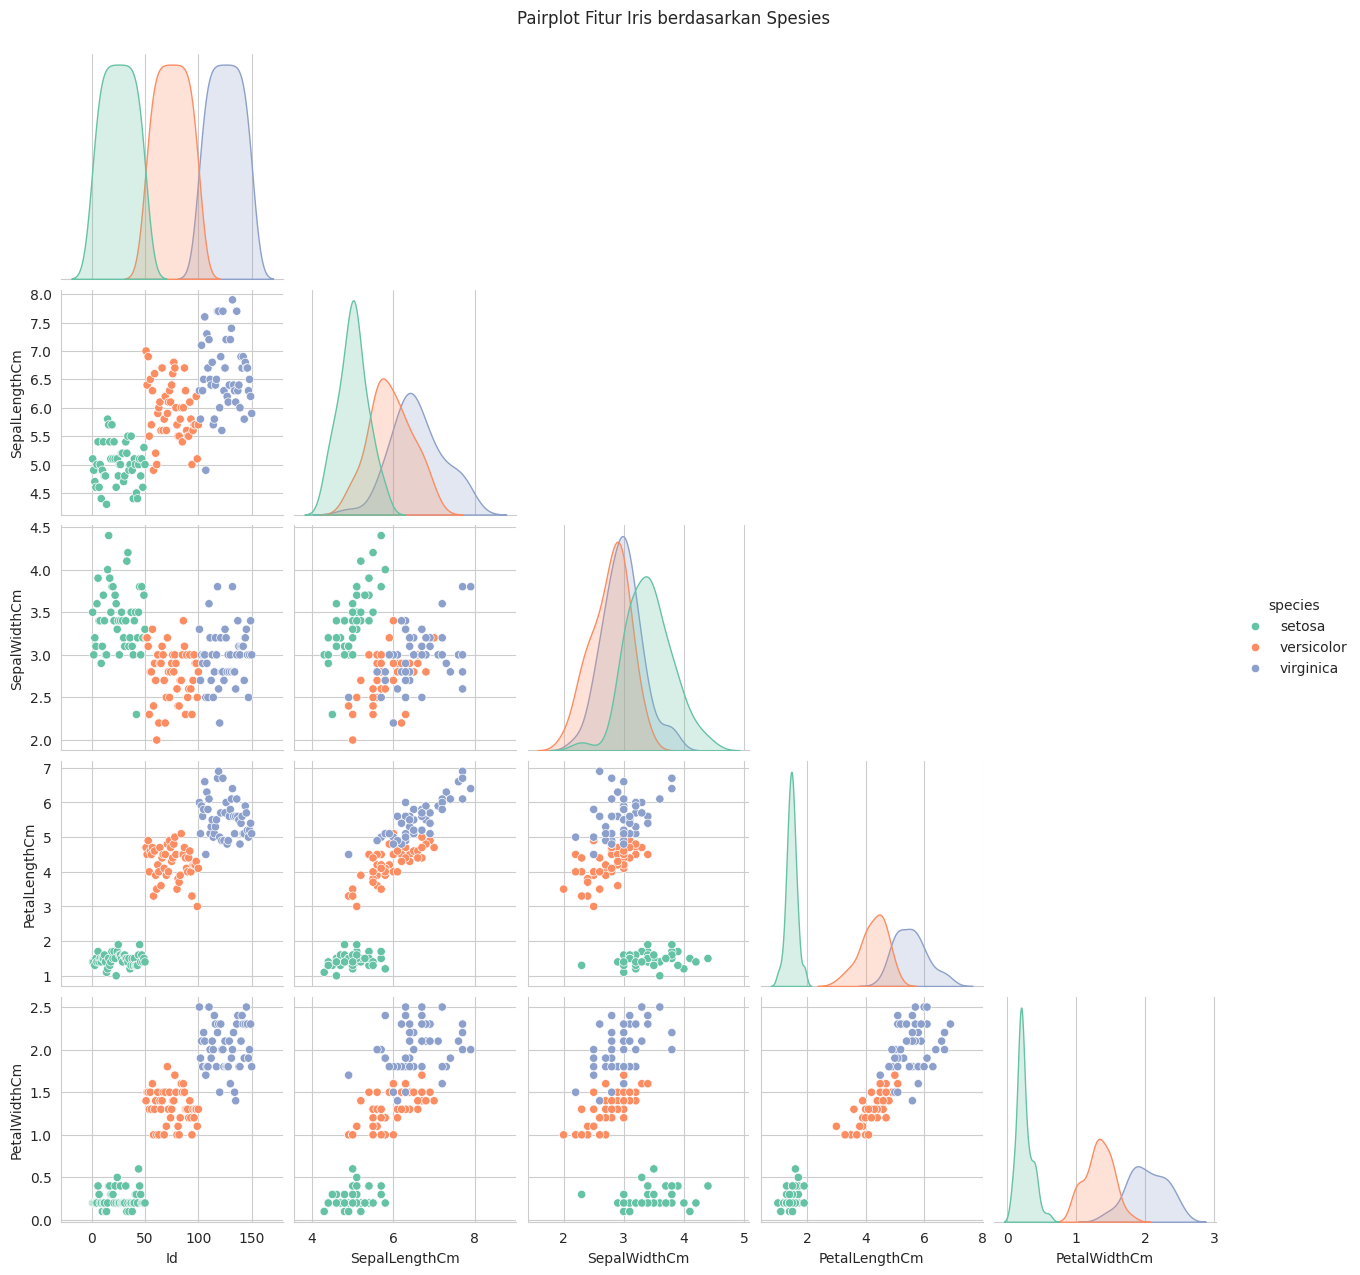

In [10]:
sns.pairplot(df, hue="species", palette="Set2", corner=True)
plt.suptitle("Pairplot Fitur Iris berdasarkan Spesies", y=1.02)
plt.show()


### 3.3 Korelasi Antar Fitur

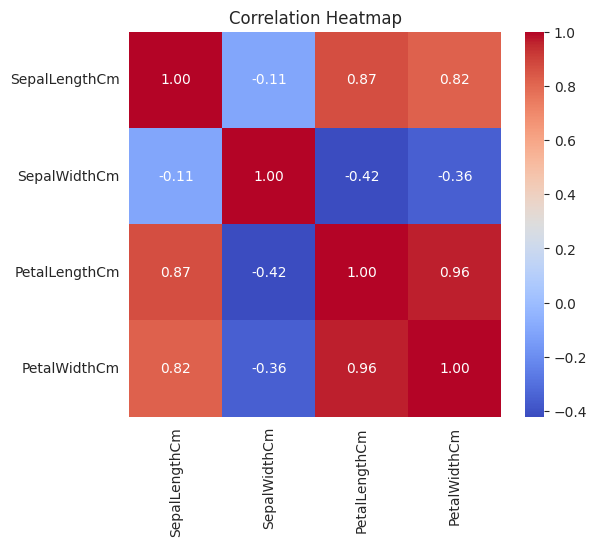

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Insight EDA:**
- Fitur `petal length` dan `petal width` punya korelasi paling kuat dan paling memisahkan ketiga spesies dengan jelas.
- Spesies *setosa* sangat mudah dipisahkan (terlihat di pairplot), sedangkan *versicolor* dan *virginica* sedikit overlap.
- Dataset seimbang (masing-masing spesies 50 data), jadi tidak perlu penanganan imbalance khusus.

## 4. Preprocessing

In [12]:
X = df[features]
y = iris.target  # encoded 0,1,2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (120, 4) | Test shape: (30, 4)


## 5. Training & Perbandingan Model

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF Kernel)": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results.append({"Model": name, "Test Accuracy": acc, "CV Accuracy (5-fold)": cv_score})

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
results_df


,Model,Test Accuracy,CV Accuracy (5-fold)
4,SVM (RBF Kernel),0.966667,0.966667
0,Logistic Regression,0.933333,0.958333
1,K-Nearest Neighbors,0.933333,0.966667
2,Decision Tree,0.900000,0.941667
3,Random Forest,0.900000,0.950000


/tmp/ipykernel_1166/4179226217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette="viridis")


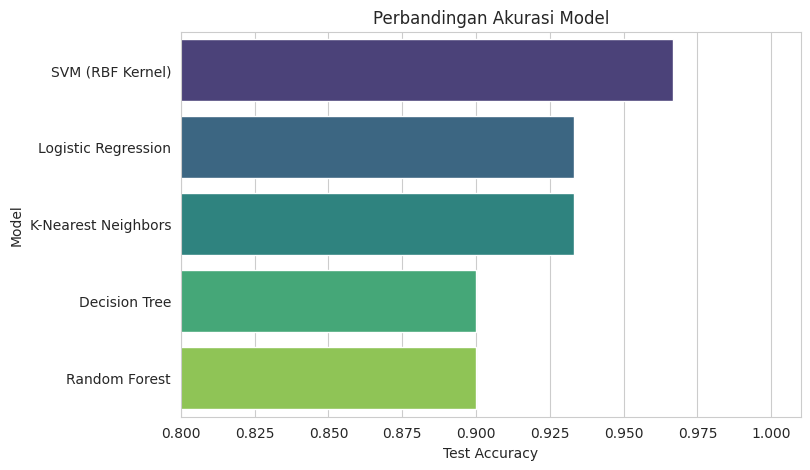

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette="viridis")
plt.xlim(0.8, 1.01)
plt.title("Perbandingan Akurasi Model")
plt.show()


## 6. Evaluasi Model Terbaik (Detail)

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Model terbaik: {best_model_name}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))


Model terbaik: SVM (RBF Kernel)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



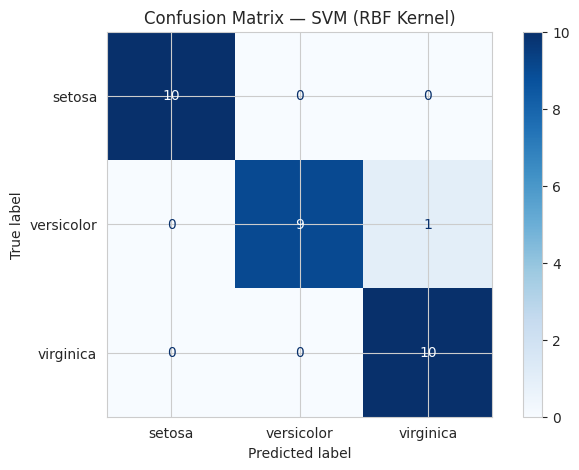

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


## 7. Feature Importance (Random Forest)

/tmp/ipykernel_1166/2709131995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


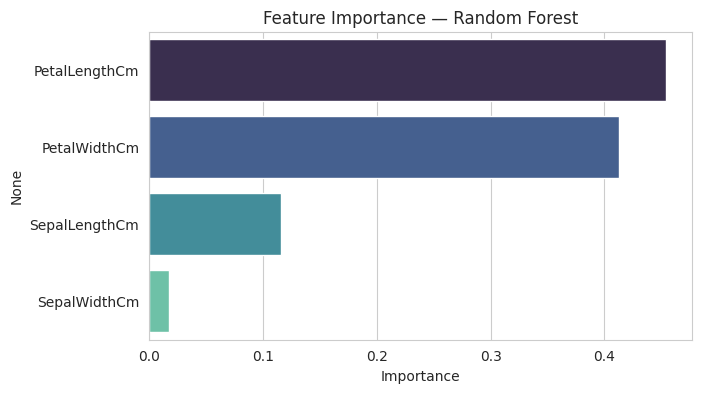

,0
PetalLengthCm,0.453793
PetalWidthCm,0.412449
SepalLengthCm,0.115873
SepalWidthCm,0.017885


In [17]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.show()

importances


## 8. Uji Coba Prediksi Manual

In [18]:
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=features)  # contoh data baru
sample_scaled = scaler.transform(sample)
pred = best_model.predict(sample_scaled)
print("Data input:", sample.values.tolist())
print("Prediksi spesies:", iris.target_names[pred[0]])


Data input: [[5.1, 3.5, 1.4, 0.2]]
Prediksi spesies: setosa


## 9. Kesimpulan

- Dataset Iris terdiri dari 150 sampel dan 3 kelas seimbang (setosa, versicolor, virginica) dengan 4 fitur numerik.
- Fitur `petal length` dan `petal width` adalah yang paling berpengaruh dalam membedakan spesies (dikonfirmasi lewat EDA dan feature importance).
- Semua model yang diuji menghasilkan akurasi tinggi (>90%), menunjukkan dataset ini relatif mudah dipisahkan (*linearly/near-linearly separable*), terutama untuk kelas *setosa*.
- Model dengan performa terbaik pada eksperimen ini akan bervariasi sedikit tergantung random state, namun secara umum SVM, Random Forest, dan Logistic Regression konsisten memberikan akurasi ≥95%.
- Kesalahan klasifikasi (jika ada) umumnya terjadi antara *versicolor* dan *virginica*, karena kedua kelas ini memiliki sedikit overlap pada fitur petal.

### Next Steps (opsional untuk pengembangan lebih lanjut)
- Hyperparameter tuning (GridSearchCV) untuk model terbaik.
- Deploy model sederhana dengan Streamlit/Gradio sebagai demo interaktif.
- Simpan model dengan `joblib` untuk keperluan deployment.
